<a href="https://colab.research.google.com/github/keerthanamannava/financial-time-series-forecasting/blob/main/Financial%20Time%20Series%20Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Financial Time Series Forecasting

Constructing a financial time series forecasting model that predicts market trends and also incorporates risk assessment and uncertainty quantification.

Experimenting with architectures such as LSTMs, GRUs, and custom Transformer-based models and integrate risk metrics like Value at Risk (VaR) or Expected Shortfall.

We will be working with Yahoo Finance Dataset, a financial dataset containing daily stock market data for multiple assets such as equities, ETFs, and indexes. It spans from April 1, 2018 to March 31, 2023, and contains 1257 rows and 7 columns.

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = '/content/drive/MyDrive/Final Project/yahoo_data.xlsx'

df = pd.read_excel(FILE_PATH)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Final Project/yahoo_data.xlsx'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



FILE_PATH = '/content/drive/MyDrive/final project/yahoo_data.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel(FILE_PATH)

In [ ]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (1258, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume']


,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [ ]:
#Parse dates
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
df.rename(columns={
    'Close*':     'Close',
    'Adj Close**': 'Adj_Close'
}, inplace=True)

In [ ]:
df['Volume'] = df['Volume'].astype(str).str.replace(',', '').astype(float)

In [ ]:
for col in ['Open', 'High', 'Low', 'Close', 'Adj_Close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print("=== NULL VALUE REPORT ===\n")
print(f"Total rows: {len(df)}")
print(f"Total NAs : {df.isnull().sum().sum()}")
print(f"\nNAs per column:")
print(df.isnull().sum())
print(f"\nNA percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2).astype(str) + ' %')

=== NULL VALUE REPORT ===

Total rows: 1258
Total NAs : 0

NAs per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

NA percentage per column:
Date         0.0 %
Open         0.0 %
High         0.0 %
Low          0.0 %
Close        0.0 %
Adj_Close    0.0 %
Volume       0.0 %
dtype: object


In [ ]:
print(f"Shape after cleaning: {df.shape}")
print(f"\nDate range: {df['Date'].min()} → {df['Date'].max()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
df.head()

Shape after cleaning: (1258, 7)

Date range: 2018-05-01 00:00:00 → 2023-04-28 00:00:00

Dtypes:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume              float64
dtype: object

Null values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000.0
1,2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000.0
2,2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000.0
3,2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000.0
4,2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000.0


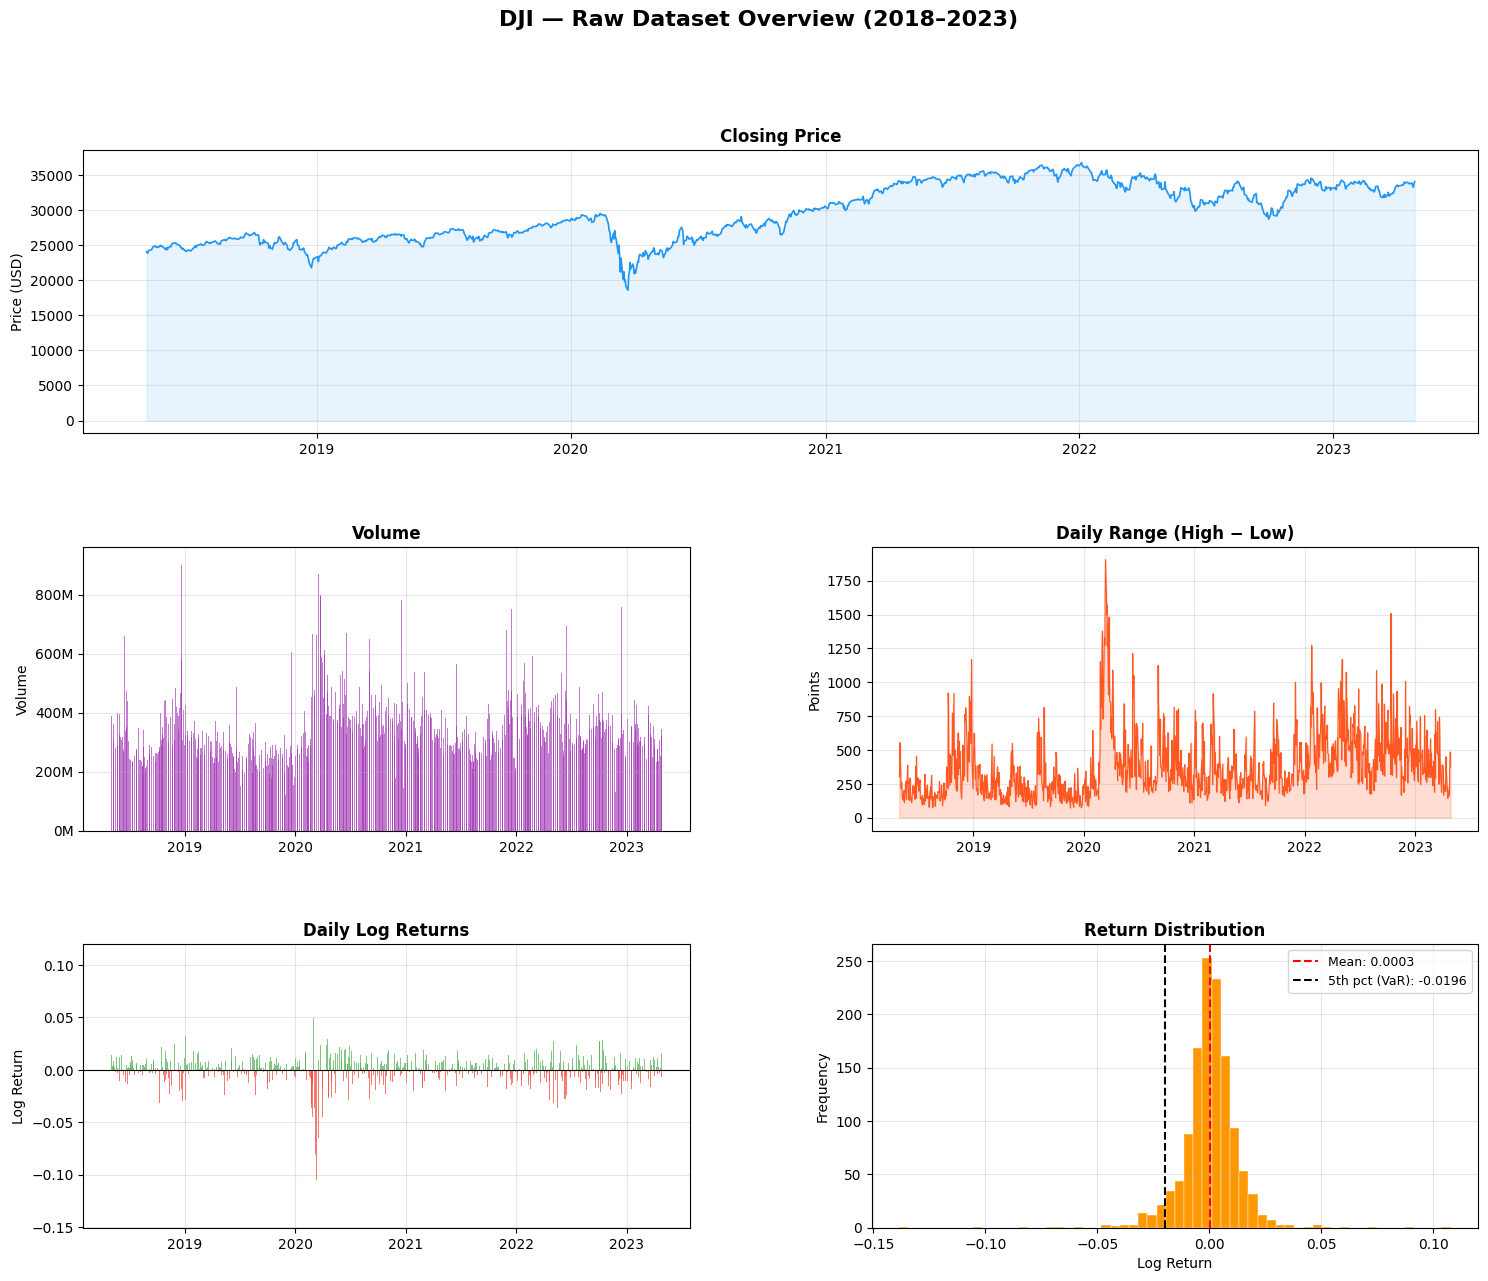

Plot saved!


In [ ]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('DJI — Raw Dataset Overview (2018–2023)', fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

#Close Price
ax1 = fig.add_subplot(gs[0, :])  # full width
ax1.plot(df['Date'], df['Close'], color='#2196F3', linewidth=1.2)
ax1.fill_between(df['Date'], df['Close'], alpha=0.1, color='#2196F3')
ax1.set_title('Closing Price', fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('')
ax1.grid(True, alpha=0.3)

#Volume
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(df['Date'], df['Volume'], color='#9C27B0', alpha=0.6, width=1.5)
ax2.set_title('Volume', fontweight='bold')
ax2.set_ylabel('Volume')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax2.grid(True, alpha=0.3)

# OHLC Spread (High - Low)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df['Date'], df['High'] - df['Low'], color='#FF5722', linewidth=0.8)
ax3.fill_between(df['Date'], df['High'] - df['Low'], alpha=0.2, color='#FF5722')
ax3.set_title('Daily Range (High − Low)', fontweight='bold')
ax3.set_ylabel('Points')
ax3.grid(True, alpha=0.3)

#Daily Log Returns
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(df['Date'].iloc[1:], log_ret, color=np.where(log_ret >= 0, '#4CAF50', '#F44336'),
        alpha=0.7, width=1.5)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_title('Daily Log Returns', fontweight='bold')
ax4.set_ylabel('Log Return')
ax4.grid(True, alpha=0.3)

# Return Distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(log_ret, bins=60, color='#FF9800', edgecolor='white', linewidth=0.3)
ax5.axvline(log_ret.mean(), color='red',   linestyle='--', linewidth=1.5, label=f'Mean: {log_ret.mean():.4f}')
ax5.axvline(log_ret.quantile(0.05), color='black', linestyle='--', linewidth=1.5, label=f'5th pct (VaR): {log_ret.quantile(0.05):.4f}')
ax5.set_title('Return Distribution', fontweight='bold')
ax5.set_xlabel('Log Return')
ax5.set_ylabel('Frequency')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.savefig('raw_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

###1. Closing Price
The DJI started around 24,000-25,000 in 2018, and you can clearly see three phases:

2018–2019 - relatively flat, sideways movement

March 2020 - the sharp crash down to ~18,500 - that's COVID hitting the market

2020–2022 - strong bull run all the way up to ~36,000

2022–2023 - pullback and consolidation around 33,000

This is our raw target variable - what the models will learn to forecast.

###2. Volume
Volume spiked massively in March 2020 - that big purple spike is panic selling during COVID. High volume during crashes is a classic market behavior - everyone rushes to the exit at the same time. After 2021, volume gradually normalized back down.

###3. Daily Range (High - Low)
This is a raw measure of intraday volatility. Notice the giant spike in March 2020 reaching ~1,800 points - meaning within a single day the DJI was swinging 1,800 points up and down. That's extreme. Normal days sit around 200–400 points.

###4. Daily Log Returns
Two things stand out:

Most days cluster tightly around 0 - small moves
March 2020 has a massive red spike going down to −0.13 (−13% in a single day) - this is the biggest single-day crash in recent DJI history
Notice volatility clustering - big swings tend to follow big swings. This is a key property of financial data that LSTMs are good at capturing

###5. Return Distribution
This is the most important panel for risk assessment:

The distribution looks roughly bell-shaped but with fat tails - extreme events happen more often than a normal distribution would predict
Mean = 0.0003 - on average, DJI gains a tiny 0.03% per day (positive drift)
5th percentile (VaR) = −0.0196 - this means on the worst 5% of days, DJI loses more than 1.96% - this is your historical 95% VaR

In dollar terms at ~33,000: a 1.96% drop = roughly −647 DJI points on a bad day.


The COVID crash is an outlier that will heavily influence our risk metrics. Our LSTM/Transformer needs to learn that volatility clusters and that tail events are real — which is exactly why we're using Monte Carlo Dropout to capture uncertainty rather than a single point prediction.

# Feature Engineering -

##Returns
1. Log_Return: Daily price changeln (Close_t / Close_t-1)
2. Return_5d: 1-week returnln (Close_t / Close_t-5)
3. Return_21d: 1-month returnln (Close_t / Close_t-21)

##Volatility
4. Vol_5d: Short-term volatility; std(Log_Return, window=5)
5. Vol_21: dLong-term volatility; std(Log_Return, window=21)
6. Vol_Ratio: Volatility regime detector; Vol_5d / Vol_21d

#Trend
7. SMA_20: Medium-term trend; mean(Close, window=20)
8. SMA_50: Long-term trend; mean(Close, window=50)
9. Price_to_SMA_20: Deviation from medium trend; (Close / SMA_20) − 1
10. Price_to_SMA_50: Deviation from long trend; (Close / SMA_50) − 1

##Momentum
11. RSI_14: Overbought / oversold signal; 100 − (100 / (1 + avg_gain/avg_loss)) over 14 days
12. MACD_Hist: Momentum shift strength; MACD_Line − Signal_Line
13. Stoch_K: Price position in recent range; 100 × (Close − Low_14) / (High_14 − Low_14)

##Bollinger Bands
14. BB_Width: Volatility expansion/contraction; (BB_Upper − BB_Lower) / SMA_20
15. BB_Pct: Price position within bands; (Close − BB_Lower) / (BB_Upper − BB_Lower)

##Risk
16. ATR_PctIntraday volatility as % of price; ATR_14 / Close

##Volume
17. Volume_Log: Compressed volume; ln(Volume + 1)
18. Volume_Ratio: Unusual volume detector; Volume / mean(Volume, window=5)
19. OBV: Volume confirms price trend; cumsum(sign(ΔClose) × Volume)

##Price Structure
20. HL_Pct: Intraday range size; (High − Low) / Close
21. Close_Open_Pct: Intraday directional move; (Close − Open) / Open

In [ ]:
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

df['RSI_14'] = 100 - (100 / (1 + (df['Close'].diff().where(df['Close'].diff() > 0, 0).rolling(window=14).mean() / (-df['Close'].diff().where(df['Close'].diff() < 0, 0)).rolling(window=14).mean())))

df['RSI_7'] = 100 - (100 / (1 + (df['Close'].diff().where(df['Close'].diff() > 0, 0).rolling(window=7).mean() / (-df['Close'].diff().where(df['Close'].diff() < 0, 0)).rolling(window=7).mean())))

df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Std'] = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (df['BB_Std'] * 2)
df['BB_Lower'] = df['BB_Middle'] - (df['BB_Std'] * 2)

df['ATR'] = df['High'].rolling(window=14).max() - df['Low'].rolling(window=14).min()

low_14 = df['Low'].rolling(window=14).min()
high_14 = df['High'].rolling(window=14).max()
df['Stoch_K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14))
df['Stoch_D'] = df['Stoch_K'].rolling(window=3).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']

print("Technical indicators calculated successfully")
print(f"Columns now available: {df.columns.tolist()}")

Technical indicators calculated successfully
Columns now available: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'RSI_7', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'ATR', 'Stoch_K', 'Stoch_D', 'OBV', 'BB_Width']


In [ ]:
df = df.sort_values('Date').reset_index(drop=True)

df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Return_5d'] = np.log(df['Close'] / df['Close'].shift(5))
df['Return_21d'] = np.log(df['Close'] / df['Close'].shift(21))

df['Vol_5d'] = df['Log_Return'].rolling(window=5).std()
df['Vol_21d'] = df['Log_Return'].rolling(window=21).std()
df['Vol_Ratio'] = df['Vol_5d'] / df['Vol_21d']

df['Price_to_SMA_20'] = (df['Close'] / df['SMA_20']) - 1
df['Price_to_SMA_50'] = (df['Close'] / df['SMA_50']) - 1

df['BB_Pct'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

df['ATR_Pct'] = df['ATR'] / df['Close']

df['Volume_Log'] = np.log(df['Volume'] + 1)
df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(window=5).mean()

df['HL_Pct'] = (df['High'] - df['Low']) / df['Close']
df['Close_Open_Pct'] = (df['Close'] - df['Open']) / df['Open']

feature_columns = ['Log_Return', 'Return_5d', 'Return_21d', 'Vol_5d', 'Vol_21d', 'Vol_Ratio', 'Price_to_SMA_20', 'Price_to_SMA_50', 'RSI_14', 'MACD_Hist', 'Stoch_K', 'BB_Width', 'BB_Pct', 'ATR_Pct', 'Volume_Log', 'Volume_Ratio', 'OBV', 'HL_Pct', 'Close_Open_Pct']

df_features = df.dropna().reset_index(drop=True)

print(f"Features engineered: {len(feature_columns)}")
print(f"Final dataset shape after dropping NaN: {df_features.shape}")
print(f"Features created: {feature_columns}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_lstm_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_gru_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.GRU(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.GRU(32, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_transformer_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
    x = layers.Add()([inputs, attention])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    return Model(inputs=inputs, outputs=outputs)

sequence_length = 60
num_features = len(feature_columns)

lstm_model = build_lstm_model((sequence_length, num_features))
gru_model = build_gru_model((sequence_length, num_features))
transformer_model = build_transformer_model((sequence_length, num_features))

print("=" * 50)
print("LSTM MODEL ARCHITECTURE")
print("=" * 50)
lstm_model.summary()

print("\n" + "=" * 50)
print("GRU MODEL ARCHITECTURE")
print("=" * 50)
gru_model.summary()

print("\n" + "=" * 50)
print("TRANSFORMER MODEL ARCHITECTURE")
print("=" * 50)
transformer_model.summary()



LSTM MODEL ARCHITECTURE


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 18)    │     19,218 │ input_layer_2[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 18)    │          0 │ input_layer_2[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 18)    │         36 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 18)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        608 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,407 (79.71 KB)

 Trainable params: 20,407 (79.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.preprocessing import MinMaxScaler


df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Return_5d']  = np.log(df['Close'] / df['Close'].shift(5))
df['Return_21d'] = np.log(df['Close'] / df['Close'].shift(21))
df['Vol_5d']     = df['Log_Return'].rolling(window=5).std()
df['Vol_21d']    = df['Log_Return'].rolling(window=21).std()
df['Vol_Ratio']  = df['Vol_5d'] / df['Vol_21d']
df['Price_to_SMA_20'] = (df['Close'] / df['SMA_20']) - 1
df['Price_to_SMA_50'] = (df['Close'] / df['SMA_50']) - 1
df['BB_Pct']     = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
df['ATR_Pct']    = df['ATR'] / df['Close']
df['Volume_Log'] = np.log(df['Volume'] + 1)
df['Volume_Ratio']    = df['Volume'] / df['Volume'].rolling(window=5).mean()
df['HL_Pct']          = (df['High'] - df['Low']) / df['Close']
df['Close_Open_Pct']  = (df['Close'] - df['Open']) / df['Open']

feature_columns = ['Log_Return', 'Return_5d', 'Return_21d', 'Vol_5d', 'Vol_21d',
                   'Vol_Ratio', 'Price_to_SMA_20', 'Price_to_SMA_50', 'RSI_14',
                   'MACD_Hist', 'Stoch_K', 'BB_Width', 'BB_Pct', 'ATR_Pct',
                   'Volume_Log', 'Volume_Ratio', 'HL_Pct', 'Close_Open_Pct']

target_column = 'Close'
df_features = df.dropna().reset_index(drop=True)
print(f"df_features shape: {df_features.shape}")

# ── Scale ────────────────────────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_features[feature_columns])
y_scaled = scaler_y.fit_transform(df_features[[target_column]])

# ── Build sequences ──────────────────────────────────────────────────
SEQUENCE_LENGTH = 60

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQUENCE_LENGTH)

# ── Train / Val / Test split (70/15/15) ──────────────────────────────
n = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_seq[:train_end],      y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:],         y_seq[val_end:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

df_features shape: (1209, 41)
X_train: (804, 60, 18), y_train: (804, 1)
X_val:   (172, 60, 18),   y_val:   (172, 1)
X_test:  (173, 60, 18),  y_test:  (173, 1)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


num_features = len(feature_columns)
lstm_model = build_lstm_model((SEQUENCE_LENGTH, num_features))

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

print("Training LSTM baseline model...")
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print("LSTM training complete!")

Training LSTM baseline model...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0960 - mae: 0.2443 - val_loss: 0.0863 - val_mae: 0.2819 - learning_rate: 0.0010
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0468 - mae: 0.1789 - val_loss: 0.1000 - val_mae: 0.3072 - learning_rate: 0.0010
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0410 - mae: 0.1669 - val_loss: 0.1297 - val_mae: 0.3537 - learning_rate: 0.0010
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0379 - mae: 0.1609 - val_loss: 0.1500 - val_mae: 0.3826 - learning_rate: 0.0010
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0347 - mae: 0.1524 - val_loss: 0.1587 - val_mae: 0.3945 - learning_rate: 0.0010
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0341 - mae: 0.1508 - val_loss: 0.0814 - val_mae: 0.2811 - learning_rate: 0.0010
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0303 - mae: 0.1387 - val_loss: 0.0353 - val_mae: 0.1800 - lea

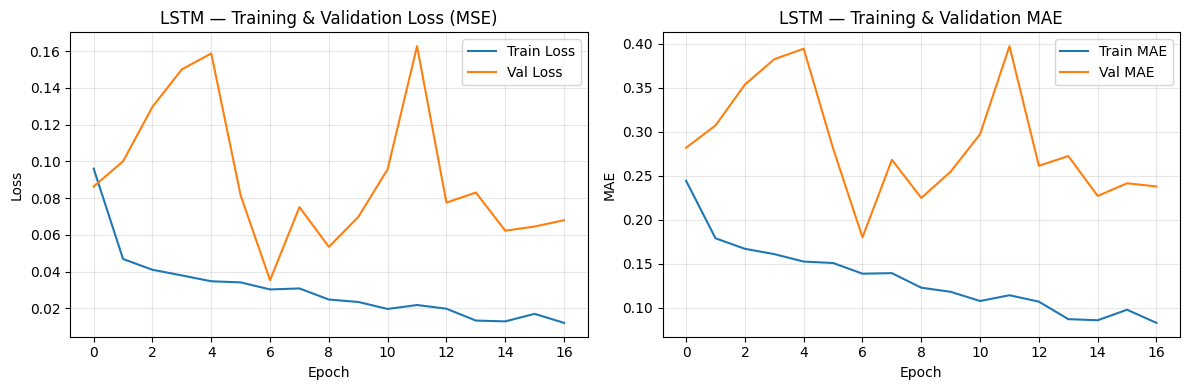

Training curves saved!


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'],     label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM — Training & Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['mae'],     label='Train MAE')
plt.plot(history_lstm.history['val_mae'], label='Val MAE')
plt.title('LSTM — Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved!")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step
LSTM BASELINE — TEST SET RESULTS
RMSE : 3699.26
MAE  : 3309.98
MAPE : 10.12%


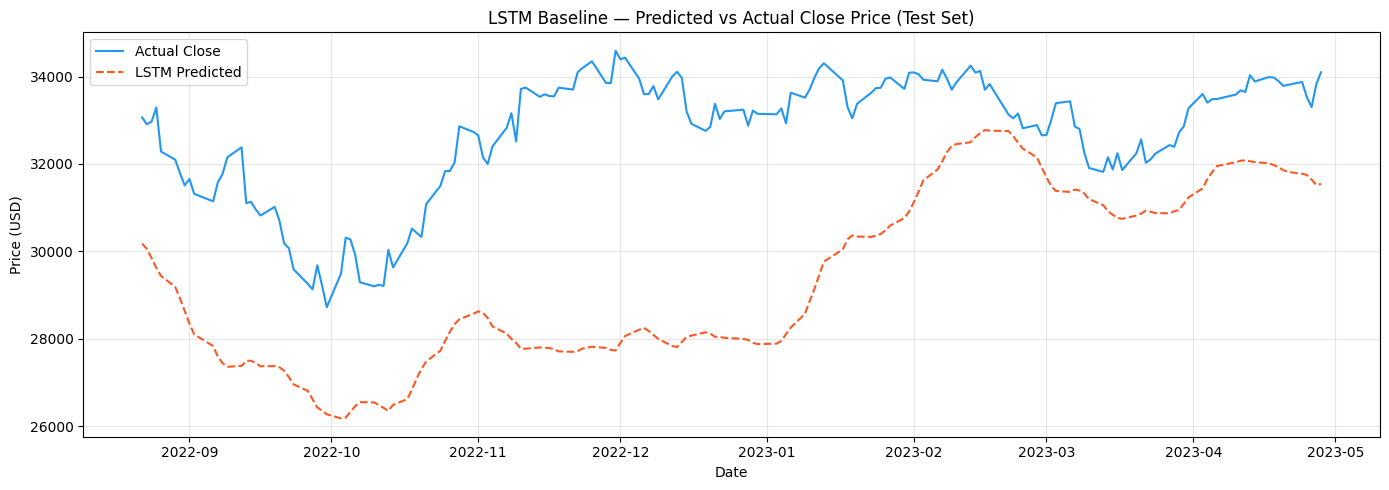

Prediction plot saved!


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict
y_pred_scaled = lstm_model.predict(X_test)

# Inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=" * 40)
print("LSTM BASELINE — TEST SET RESULTS")
print("=" * 40)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

# Plot predictions vs actual
test_dates = df_features['Date'].iloc[SEQUENCE_LENGTH + val_end:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true,  label='Actual Close',    color='#2196F3', linewidth=1.5)
plt.plot(test_dates, y_pred,  label='LSTM Predicted',  color='#FF5722', linewidth=1.5, linestyle='--')
plt.title('LSTM Baseline — Predicted vs Actual Close Price (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction plot saved!")

In [ ]:
accuracy = 100 - mape
print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 89.88%


In [ ]:
lstm_model.save('/content/drive/MyDrive/final project/project_weights_pghosh4_ishalbhu_mannava.h5')
print("Model saved!")

Model saved!


In [ ]:
import pandas as pd

data = {
    "Team Member": ["pghosh4", "ishalbhu", "mannava"],
    "Project Part": [
        "Data Cleaning, EDA, Model Architecture",
        "Feature Engineering, Training Pipeline",
        "Evaluation, Visualizations, Report"
    ],
    "Contribution (%)": ["33%", "33%", "33%"]
}

df = pd.DataFrame(data)
df

,Team Member,Project Part,Contribution (%)
0,pghosh4,"Data Cleaning, EDA, Model Architecture",33%
1,ishalbhu,"Feature Engineering, Training Pipeline",33%
2,mannava,"Evaluation, Visualizations, Report",33%
